In [32]:
### Goal: Train a Linear Regression as the first model.
## Evaluate using R² on the test set.
## Record baseline results.

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt

le = LabelEncoder()




In [ ]:
df_train = pd.read_csv('train_housing.csv')
df_test = pd.read_csv('test_housing.csv')
print (df_train.head(), df_test.head())
print (df_train.shape, df_test.shape)


drop_cols = [
    'ClosePrice',
    'CloseDate',
    'ListingContractDate',
    'PurchaseContractDate',
    'ContractStatusChangeDate',
    'ListingId',
    'ListingKey',
]

X_train = df_train.drop(columns=drop_cols, errors='ignore')
y_train = df_train['ClosePrice']

X_test = df_test.drop(columns=drop_cols, errors='ignore')
y_test = df_test['ClosePrice']


## check for categorical columns first

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

bool_like = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 
             'NewConstructionYN', 'FireplaceYN']

true_cat_cols = [col for col in cat_cols if col not in bool_like]

##distinguish boolean-like columns from true categorical columns
print(f"Boolean columns: {bool_like}")
print(f"True categorical columns: {true_cat_cols}")






  ViewYN PoolPrivateYN  OriginalListPrice  ListingKey   CloseDate  ClosePrice  \
0  False         False          1130000.0   538338723  2024-09-12   1090000.0   
1   True          True          1995000.0  1089077716  2024-09-30   1995000.0   
2   True          True          2340000.0  1089076111  2024-09-30   2340000.0   
3   True          True           984000.0  1089075731  2024-09-30    984000.0   
4   True         False          1250000.0  1089075621  2024-09-30   1225000.0   

    Latitude   Longitude PropertyType  LivingArea  ...  Levels  LotSizeArea  \
0  34.136660 -118.012799  Residential      2655.0  ...     One      14390.0   
1  33.804370 -116.439882  Residential      3524.0  ...     One      18295.0   
2  33.515988 -117.706900  Residential      2988.0  ...     Two      11900.0   
3  32.799141 -117.017206  Residential      1573.0  ...     One       6500.0   
4  34.024425 -117.136006  Residential      2889.0  ...     One       5338.0   

  MainLevelBedrooms NewConstructionYN 

/var/folders/_x/x2tsp53j6qnc79kydrrx_hkm0000gn/T/ipykernel_94668/3425802428.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [ ]:


# boolean-like columns: map True/False to 1/0
# true categorical columns: use LabelEncoder to convert to numeric values
from sklearn.preprocessing import LabelEncoder


for col in bool_like:
    if col in X_train.columns:
        X_train[col] = X_train[col].map({True: 1, False: 1, 
                                          'True': 1, 'False': 0,
                                          '1': 1, '0': 0}).fillna(0)
        X_test[col] = X_test[col].map({True: 1, False: 1,
                                        'True': 1, 'False': 0,
                                        '1': 1, '0': 0}).fillna(0)

## Fit on combined train + test to capture all categories

le_dict = {}

for col in true_cat_cols:
    encoder = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).reset_index(drop=True)
    encoder.fit(combined)
    X_train[col] = encoder.transform(X_train[col].astype(str))
    X_test[col] = encoder.transform(X_test[col].astype(str))
    le_dict[col] = encoder

print("Encoding done!")
print(X_train.dtypes.value_counts())



Encoding done!
int64      18
float64    16
Name: count, dtype: int64


In [28]:
from sklearn.impute import SimpleImputer

train_mask = y_train.notna()
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_mask = y_test.notna()
X_test, y_test = X_test[test_mask], y_test[test_mask]

imputer = SimpleImputer(strategy="median")  # median is robust for housing data
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)


#get rid of NaN values in y_train and y_test

print(X_train.isna().sum())
print(X_test.isna().sum())
print(y_train.isna().sum(), y_test.isna().sum())


print(np.isnan(X_train_imp).sum())  # should be 0
print(np.isnan(X_test_imp).sum())


ViewYN                       0
PoolPrivateYN                0
OriginalListPrice          415
Latitude                    27
Longitude                   27
PropertyType                 0
LivingArea                 112
DaysOnMarket                 0
ListingKeyNumeric            0
MLSAreaMajor                 0
CountyOrParish               0
MlsStatus                    0
AttachedGarageYN             0
ParkingTotal                 2
PropertySubType              0
LotSizeAcres              3762
BuyerOfficeAOR               0
YearBuilt                  157
StreetNumberNumeric        255
BathroomsTotalInteger       27
City                         0
BedroomsTotal                0
FireplaceYN                  0
Stories                  25824
Levels                       0
LotSizeArea               3727
MainLevelBedrooms            0
NewConstructionYN            0
GarageSpaces              8377
HighSchoolDistrict           0
PostalCode                   0
AssociationFee               0
LotSizeS

In [29]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [30]:
#evaluate the model using R² on the test set
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"R² Score: {r2}")
print(f"Mean Squared Error: {rmse}")
print(f"MAPE: {mape:.2f}%")

R² Score: 0.3327407381223757
Mean Squared Error: 1370739.1717281544
MAPE: 33.46%


Text(0, 0.5, 'Predicted ClosePrice')

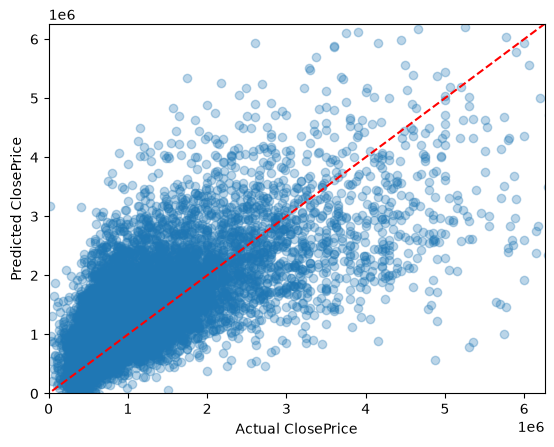

In [34]:
plt.scatter(y_test, y_pred, alpha=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')

# zoom to where most of the data actually is
upper = np.percentile(y_test, 99)   # ignore the top 1% outliers
plt.xlim(0, upper)
plt.ylim(0, upper)
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")

In [35]:
import joblib

joblib.dump(model, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved!")

Model saved!
